In [163]:
#Importando as bibliotecas necessárias
import pandas as pd # Responsavel por manipular os dados
import matplotlib.pyplot as plt # Responsavel por criar os gráficos
import seaborn as sns 
from scipy.stats import linregress, pearsonr # Responsavel por calcular a regressão linear e a correlação de Pearson

In [164]:
# Carrega os dados (o arquivo não tem cabeçalho, então nomeamos as colunas)
colunas = ['Vendor', 'Model', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']
#Tal que:
# Vendor = Fabricante
# Model = Modelo
# MYCT = Tempo de ciclo mínimo (em nanosegundos)
# MMIN = Memória RAM Mínima (em KB)
# MMAX = Memória RAM Máxima (em KB)
# CACH = Memória Cache (em KB)
# CHMIN = Canais mínimo do cache (em KB)
# CHMAX = Canais máximo do cache (em KB)
# PRP = Desempenho Medido
# ERP = Desempenho Estimado

In [165]:
# Carrega os dados do arquivo CSV
df = pd.read_csv('machine.data', names=colunas)


Nota-se que o grafico vai aumentando suas medidas em potencias de dois, ou seja quando estamos com 8000 KB seu proximo salto instavel 
(Como se estivesse formando uma coluna) é em 16000 KB. Para 16000 o proximo salto é 32000 e ocorre o mesmo.

Em um nivel de significancia de 1% (O alfa = 1%) diriamos que:
nossa hipotese nula: é de que as variaveis não tem correlação;
nossa hipotese alternativa: é de que elas tem correlação;

Correlação de Pearson: 0.8630
Valor-p: 2.6489e-63

Como assumimos um nivel de significancia igual a 0.01 (1%) e verificamos que o nosso p-valor é bem abaixo de 1. A Hipotese que tinhamos
de que não tem correlação não pode ser aceita. 
Em termos leigos, estamos basicamente dizendo que nas maquinas aferidas, a chance de que tenha sido mero acaso que todas elas tivesse o efeito
'aumenta ram logo aumenta performance' não é apenas coincedencia, é estastica certa de que se aumenta um aumenta o outro tambem.


Para a equação de regressão linear, temos:
Equação de Regress

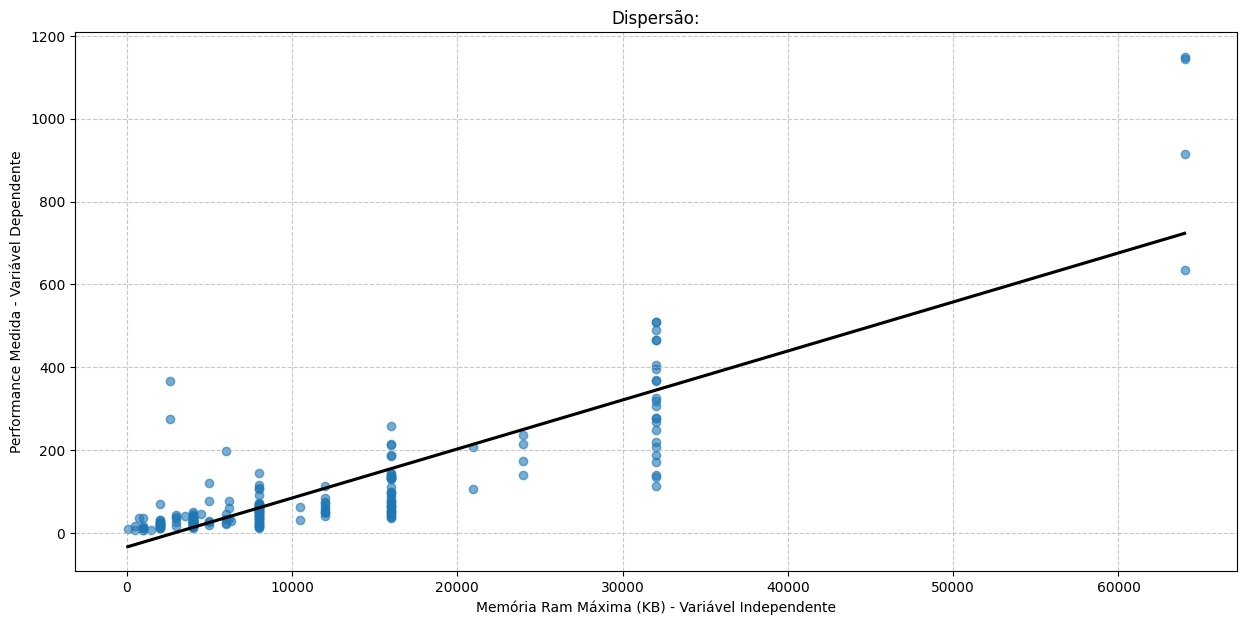

In [166]:
# Separando X (MMAX) e Y (PRP)
X = df['MMAX']
Y = df['PRP']
#MMAX (Memória RAM Máxima) é a variável independente, ou seja, aquela que influencia o desempenho do computador
#PRP (Desempenho Medido) é a variável dependente, ou seja, aquela que é influenciada pela memória RAM máxima

#Constrói o Diagrama de Dispersão
plt.figure(figsize=(15, 7))
sns.regplot(x=X, y=Y, scatter_kws={'alpha':0.6}, line_kws={'color':'black'}, ci=None)
plt.title('Dispersão:')
plt.xlabel('Memória Ram Máxima (KB) - Variável Independente')
plt.ylabel('Performance Medida - Variável Dependente')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Lei_de_moore.png')
print("="*150)
print("\nNota-se que o grafico vai aumentando suas medidas em potencias de dois, ou seja quando estamos com 8000 KB seu proximo salto instavel \n(Como se estivesse formando uma coluna) é em 16000 KB. Para 16000 o proximo salto é 32000 e ocorre o mesmo.\n")
print("="*150)
print("Em um nivel de significancia de 1% (O alfa = 1%) diriamos que:")
print("nossa hipotese nula: é de que as variaveis não tem correlação;")
print("nossa hipotese alternativa: é de que elas tem correlação;\n")

#Calcula a correlação de Pearson das variáveis X e Y
correlacao, p_valor = pearsonr(X, Y)
print(f"Correlação de Pearson: {correlacao:.4f}")
print(f"Valor-p: {p_valor:.4e}\n")
print("Como assumimos um nivel de significancia igual a 0.01 (1%) e verificamos que o nosso p-valor é bem abaixo de 1. A Hipotese que tinhamos\nde que não tem correlação não pode ser aceita. ")
print("Em termos leigos, estamos basicamente dizendo que nas maquinas aferidas, a chance de que tenha sido mero acaso que todas elas tivesse o efeito\n'aumenta ram logo aumenta performance' não é apenas coincedencia, é estastica certa de que se aumenta um aumenta o outro tambem.\n")
print("="*150)
print("\nPara a equação de regressão linear, temos:")
res = linregress(X, Y)
beta_0 = res.intercept
beta_1 = res.slope
print(f"Equação de Regressão: Y = {beta_0:.4f} + {beta_1:.4f} * X\n")
print("Relembrando o que significa a equação de Regressão: Uma ferramente estatistica que modela um a relação entre variaveis assim permitindo prever o comportamento dos dados a partir de um certo historico que ele tenha, dado que os dados tenham uma correlação valida")

Em um nivel de significancia de 1% (O alfa = 1%) diriamos que:
nossa hipotese nula: é de que as variaveis não tem correlação;
nossa hipotese alternativa: é de que elas tem correlação;

Correlação de Pearson: 0.6626
Valor-p: 8.5053e-28

Como assumimos um nivel de significancia igual a 0.01 (1%) e verificamos que o nosso p-valor é bem abaixo de 1. A Hipotese que tinhamos
de que não tem correlação não pode ser aceita. 
Em termos leigos, estamos basicamente dizendo que nas maquinas aferidas, a chance de que tenha sido mero acaso que todas elas tivesse o efeito
'aumento de performance devido a aumento de memória cache' não é apenas coincedencia, é estastica certa de que se aumenta um aumenta o outro tambem.


Para a equação de regressão linear, temos:
Equação de Regressão: Y = -33.9992 + 0.0118 * X

Relembrando o que significa a equação de Regressão: Uma ferramente estatistica que modela um a relação entre variaveis assim permitindo prever o comportamento dos dados a partir de um certo hist

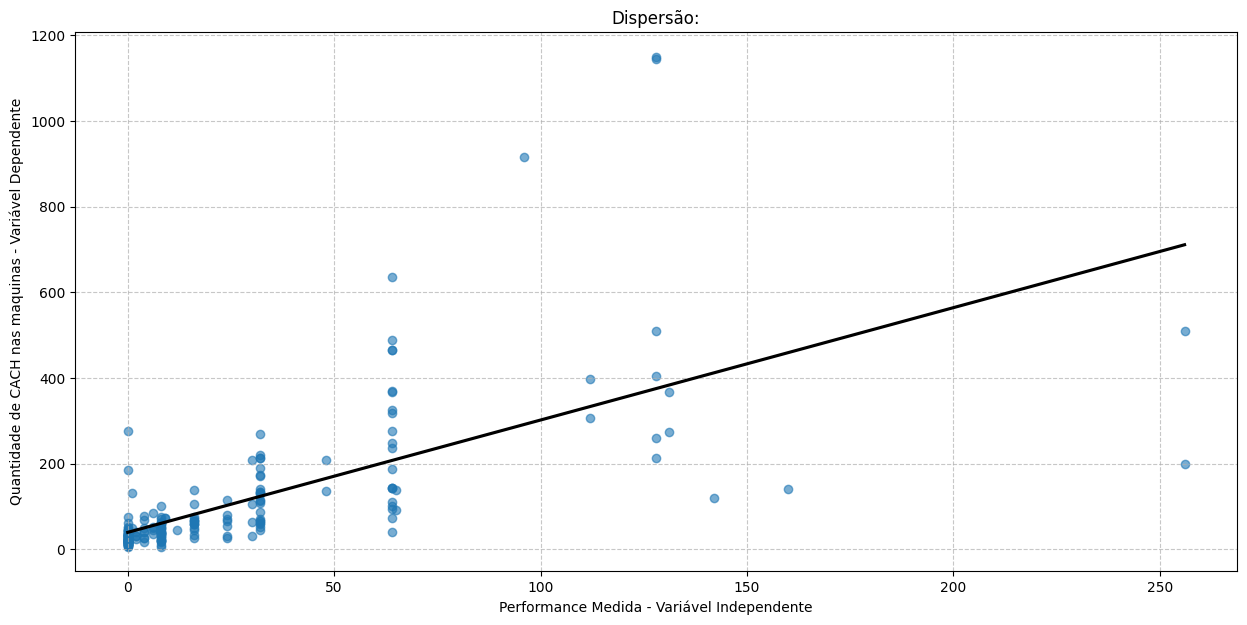

In [167]:
# Separando X (CACH) e Y (PRP)
X = df['CACH']
Y = df['PRP']
# X = CACH (Memoria cache) é a variável independente, ou seja, aquela que influencia o desempenho do computador
# Y = PRP (Desempenho Medido) é a variável dependente, ou seja, aquela que é influenciada pela memória cache

#Constrói o Diagrama de Dispersão
plt.figure(figsize=(15, 7))
sns.regplot(x=X, y=Y, scatter_kws={'alpha':0.6}, line_kws={'color':'black'}, ci=None)
plt.title('Dispersão:')
plt.xlabel('Performance Medida - Variável Independente')
plt.ylabel('Quantidade de CACH nas maquinas - Variável Dependente')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('grafico_dispersao_hardware.png')
print("="*150)
print("Em um nivel de significancia de 1% (O alfa = 1%) diriamos que:")
print("nossa hipotese nula: é de que as variaveis não tem correlação;")
print("nossa hipotese alternativa: é de que elas tem correlação;\n")

#Calcula a correlação de Pearson das variáveis X e Y
correlacao, p_valor = pearsonr(X, Y)
print(f"Correlação de Pearson: {correlacao:.4f}")
print(f"Valor-p: {p_valor:.4e}\n")
print("Como assumimos um nivel de significancia igual a 0.01 (1%) e verificamos que o nosso p-valor é bem abaixo de 1. A Hipotese que tinhamos\nde que não tem correlação não pode ser aceita. ")
print("Em termos leigos, estamos basicamente dizendo que nas maquinas aferidas, a chance de que tenha sido mero acaso que todas elas tivesse o efeito\n'aumento de performance devido a aumento de memória cache' não é apenas coincedencia, é estastica certa de que se aumenta um aumenta o outro tambem.\n")
print("="*150)
print("\nPara a equação de regressão linear, temos:")
print(f"Equação de Regressão: Y = {beta_0:.4f} + {beta_1:.4f} * X\n")
print("Relembrando o que significa a equação de Regressão: Uma ferramente estatistica que modela um a relação entre variaveis assim permitindo prever o comportamento dos dados a partir de um certo historico que ele tenha, dado que os dados tenham uma correlação valida")
